# 02 Milk price (second outcome): ingest, DiD, synthetic control, inference

Parallel notebook to `01_data` (deliveries), now for the **farm-gate milk price**. Same identification design and the same reusable modules; only the *outcome* changes.

- **Input:** EU Milk Market Observatory Excel (`data/raw/EU_Milk_Price_2010_to_2019.xlsx`), raw milk price, €/100 kg, monthly and the deliveries panel `data/processed/panel.parquet` from `01_data` (EU-28 frame, 2010–2019 window, treatment flags).
- **Output:** `data/processed/panel_price.parquet`, columns `geo, date, milk_deliveries, milk_price, treated, post, treated_post`.
- **Pipeline position:** `01_data` (quantity) → **`02_price`** (this) → income finale.
- **Local modules:** `ingest_price.py` (`load_price`, `merge_price`, `CODE2GEO`), `estimation.py`, `synth.py` — all `outcome`-parametrised.

## 0. Roadmap & the decisions already settled

**Steps:**
1. Load the deliveries panel (the EU-28, windowed, treated frame).
2. Load the MMO price series and verify the country-code mapping (`CODE2GEO`).
3. Merge price onto the panel.
4. Sanity checks, price-specific (coverage, absences, positivity, treated set).
5. Fix the analysis frame + settle the **donor-coverage policy** (the one open decision).
6. First look at parallel trends (indexed).
7. Event study (DiD), `outcome="milk_price"`.
8. Synthetic control (standard) → 9. Augmented (ridge) SC.
10. Triangulation SC vs DiD. → 11. Placebo / group-permutation inference.
12. Income finale (price × quantity). → Conclusions.

**Settled conceptual decisions for price (from the decision log — read before running):**
- Price is an **independent** analysis, *not* forced onto the quantity sample.
- The **treatment definition is identical** across outcomes (the 12 binding MS) — "binding" is a property of the policy, not the outcome. Non-negotiable.
- **Controls and fit-based exclusions are outcome-specific and free.** The UK is absent from the price series (control 15 → 14); dropping Ireland for *quantity* does **not** force dropping it for *price*. Same objective criteria, re-applied to the price series.
- **Economic prior:** supply ↑ ⇒ price ↓ ⇒ expect a **negative** effect (opposite sign to quantity). The policy story: more volume *but* lower price ⇒ ambiguous for farmers.

**The one open decision (settled at step 5, before any SC fit):** how to treat **partial-coverage donors** (Croatia from 2013, plus LU/RO/EE gaps). See step 5.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ingest_price
from treatment import ABOLITION_DATE, BINDING_COUNTRIES
import estimation as est
import synth

In [2]:
pd.set_option("display.max_columns", 30)
PROC = Path("data/processed")
RAW = Path("data/raw")
PRICE_XLSX = RAW / "EU_Milk_Price_2010_to_2019.xlsx"
PROC.mkdir(parents=True, exist_ok=True)

## 1. Build the price panel

### Why the price comes from a different source than the quantity

The deliveries outcome came from Eurostat (`apro_mk_colm`). The farm-gate price does **not** live there, Eurostat publishes collected quantities and fat/protein content, but not the price paid to farmers. That series is published instead by the **Milk Market Observatory** (agridata.ec.europa.eu, "Raw milk prices"): monthly, **EUR/100 kg**, built from Member-State notifications via ISAMM. Two consequences follow immediately and shape everything downstream: the file is an **Excel export, not an API**, so the generic Eurostat `fetch_long` does not apply; and the export is **EU-27, the United Kingdom is absent**. The UK was a valid control for deliveries; for price it simply does not exist, so the price control group is smaller by construction, not by choice.

### The country-code trap, and why the mapping is verified

The MMO does not label countries with Eurostat geo codes. It uses **EU protocol-order numbers**, Belgium=10, Bulgaria=20, …, Sweden=260, with **Croatia inserted as 105** (it joined in 2013 and was slotted between France=100 and Italy=110 without renumbering the rest). Nothing aligns with the deliveries panel until those numbers are translated, so `CODE2GEO` maps each one to its Eurostat code. This is the price analogue of the deliveries "confirm the dimension codes" step, and it carries the same recurring gotcha (Greece is `EL`, the UK would be `UK`): a single mis-mapped code would silently relabel a country. So `load_price` does not assume the mapping is complete, it **fails loud** on any code it cannot translate, rather than dropping a country quietly.

### One decision carried over, everything else independent

The price analysis is built **from the price data alone**. The *only* thing inherited from the quantity project is the **definition of the treated group**: the 12 Member States whose quota was binding (a positive quota shadow price, the constraint was actually pressing). That is deliberate and defensible: "binding" is a property of the **policy**, not of the outcome we happen to measure. A country whose quota bit on its production volume is the same country whether we then look at its volume or its price.

Everything else is re-derived from the price series and **not** imported from the deliveries sample. The controls are whatever EU-27 non-binding countries the price data contains; sample restrictions and fit-based exclusions (coverage, pre-RMSPE) are decided later on their own merits, against the price data. Forcing the quantity sample onto the price, its Malta drop, its Ireland exclusion, would be *less* rigorous, not more: those calls were answers to questions the deliveries data asked, and the price data asks its own.

### From price to a DiD panel: the treatment and period flags

`build_price_panel` reuses `load_price` for the parsing and mapping, then stamps the three flags that turn a plain series into a difference-in-differences panel:

- **`treated`**: 1 for the binding Member States, else 0. It is a property of the **country, constant over time**: a country either was or was not constrained, and that status does not change month to month.
- **`post`**: 1 from the **April-2015** abolition onward. The time switch at the break.
- **`treated_post`**: their interaction, the single term whose coefficient will carry the causal estimate once country and month fixed effects absorb everything else.

The result is one row per country-month, with the outcome in `milk_price`. And because a mis-mapped geo would corrupt the treated/control split before any estimation, the step **asserts every binding country is present** and halts otherwise — the cheapest insurance against the `EL`/`UK` trap.

In [3]:
# We build the panel following the format described above and the format of mill_deliveries project.
panel = ingest_price.build_price_panel(PRICE_XLSX)
panel.head()

,geo,date,milk_price,treated,post,treated_post
0,AT,2010-01-01,30.89,1,0,0
1,AT,2010-02-01,30.62,1,0,0
2,AT,2010-03-01,30.34,1,0,0
3,AT,2010-04-01,29.74,1,0,0
4,AT,2010-05-01,29.96,1,0,0


## 2. Sanity checks

### Auditing the panel before trusting it

The most dangerous data error is not the one that crashes, it is the one that produces a plausible-looking number. A wrong country count, an unbalanced panel, or hidden missingness won't raise an exception; they will quietly bias a causal estimate that we then present with confidence. So before any plot or regression we audit the panel against what we *believe* it to be. The check is cheap; an undetected error downstream is not. This is the same fail-loud, audit-first stance already built into `load_price` (which halts on any unmapped country code) and `build_price_panel` (which halts if a binding country is missing), now applied to the assembled panel as a whole.

Each check targets a specific failure mode, not a generic "does it look ok":

- **Date range.** Confirms the time parsing worked and the coverage is what we expect. The price export is already delivered for 2010–2019, so unlike the deliveries panel (which spanned 1968–2026 and had to be windowed) this one should land on exactly that band, a stray or truncated date here would betray a malformed `Year`/`Month` parse.

- **Treated count, control count, and the two group lists.** Confirms the treated/control split is what the design intends. The treated set must be **exactly the 12 binding Member States**, a mis-mapped geo code (the recurring `EL`/`UK` trap) would silently move a country across the split and corrupt the entire estimate, so this is checked with an `assert` and we'd rather halt than proceed on a wrong sample. The control count, by contrast, is **read, not asserted**: it is whatever EU-27 non-binding countries the price data happens to contain. We already expect it to differ from the deliveries analysis because the **UK is absent** from the MMO export,  confirming that absence here is part of the point, not an error.

- **Observations per country (min / median / max).** A balance check. A large spread means some countries are observed far less than others, which bears directly on the design: a country with only a partial series cannot anchor a pre-trend or serve as a clean synthetic-control donor. We expect this spread to be wider than for deliveries, because price coverage is uneven (Croatia, for instance, only reports from 2013).

- **Countries with gaps, and how many months each is missing.** This is the real completeness test, and the reason a simple "missing values = 0" count would be misleading. `load_price` already drops rows with no price, so a missing-value tally reflects *our own filtering*, not the true coverage, a country could be missing whole months and still show zero NaNs, simply because those rows never entered the panel. The honest test is whether each country has an **unbroken monthly series** across 2010–2019: we compare each country's observed months against the full 120-month grid and list exactly who falls short and by how much. The *count* of gaps is only the first half — *where* they fall (a block in the pre-period vs scattered, or all in 2019) decides whether a gap is harmless to DiD, disqualifying for synthetic control, or irrelevant, but locating that comes in the next step; here we surface who needs that closer look.

The thread running through all five: **trust nothing about the data we have not explicitly verified.** The audit does its job not by rubber-stamping the panel but by generating the next decision, which countries' gaps need diagnosing before we can read a parallel-trends plot or fit a credible counterfactual.

In [4]:
# Treated / control split and the two group lists.
treated = sorted(panel.loc[panel.treated == 1, "geo"].unique())
control = sorted(panel.loc[panel.treated == 0, "geo"].unique())

print("date range :", panel.date.min().date(), "→", panel.date.max().date())
print("n countries:", panel.geo.nunique(),
      "| treated:", len(treated), "| control:", len(control))
print("treated    :", treated)
print("control    :", control)

# Observations per country (price months actually present).
counts = panel.groupby("geo").size()
print("\nobs per country  min/median/max:",
      counts.min(), int(counts.median()), counts.max())

# Completeness against the full 2010–2019 monthly grid (120 months): a NaN tally
# would be misleading because load_price already dropped price-less rows, so we
# compare observed months to the grid instead.
full = pd.date_range("2010-01-01", "2019-12-01", freq="MS")
gaps = (len(full) - counts)
gaps = gaps[gaps > 0].sort_values(ascending=False)
print("\ncountries with gaps (missing months out of 120):")
if len(gaps):
    for g, n in gaps.items():
        print(f"  {g}: {int(n)} missing")
else:
    print("  none — every country has the full 120 months")

# Fail loud: the treated set must be exactly the 12 binding Member States.
expected = set(ingest_price.BINDING_COUNTRIES)
assert set(treated) == expected, f"treated set mismatch: {expected ^ set(treated)}"

date range : 2010-01-01 → 2019-12-01
n countries: 27 | treated: 12 | control: 15
treated    : ['AT', 'BE', 'CY', 'DE', 'DK', 'EE', 'ES', 'IE', 'IT', 'LU', 'NL', 'PL']
control    : ['BG', 'CZ', 'EL', 'FI', 'FR', 'HR', 'HU', 'LT', 'LV', 'MT', 'PT', 'RO', 'SE', 'SI', 'SK']

obs per country  min/median/max: 78 120 120

countries with gaps (missing months out of 120):
  HR: 42 missing
  LU: 13 missing
  MT: 7 missing
  RO: 3 missing
  EE: 2 missing
  BG: 1 missing
  DE: 1 missing
  NL: 1 missing
  SE: 1 missing


### What the checks confirm, and the gaps they expose

The structural checks pass cleanly. The date range is **exactly 2010-01 → 2019-12**, so the `Year`/`Month` parse is sound and the export needs no windowing, it arrives on precisely the band the design wants. The split is **12 treated / 15 control** and the `assert` passed: the treated set is exactly the twelve binding Member States, the `CODE2GEO` mapping put every country where it belongs, and the `EL`/`UK` trap did not bite. The control count, **15**, is read rather than asserted, and it confirms the expected structural difference from the deliveries analysis: the **UK is absent** from the MMO export (EU-27 only), so it is simply not a price control. The control list also shows that Malta and Croatia are *present* in the price data, a contrast with deliveries worth keeping in mind, since their fate here must be decided on the price evidence, not inherited.

The completeness check is where the real work surfaces. Observations per country run **78 / 120 / 120**: the median country has its full unbroken series, but the minimum is 78, and the gap list names who falls short. Nine countries are incomplete, and they fall into two clearly different magnitudes:

- **One large gap, Croatia (HR), 42 missing.** This is structural, not noise: Croatia joined the EU in 2013 and only reports from then, so it is missing roughly the first three pre-treatment years. That is precisely the part of the window a pre-trend and a synthetic-control fit depend on, which makes HR the first country whose role we have to reconsider.
- **One moderate gap, Luxembourg (LU), 13 missing**, a treated country, so not droppable lightly; ~11% of the window, no longer negligible.
- **A cluster of small gaps, MT 7, RO 3, EE 2, and BG / DE / NL / SE at 1 each.** Individually these look immaterial, but a raw count cannot tell us that yet.

This is the same lesson the deliveries audit taught: **a count of missing months is not enough to act on.** The same number means very different things depending on *where* the gaps fall. Twelve scattered months are benign; twelve consecutive pre-2015 months would wreck a country's parallel-trends reading. A control with no pre-period cannot serve as a counterfactual at all, while the identical gap in a treated country may cost almost nothing. And the treated/control asymmetry matters: a weak control can simply be dropped (the design only gets cleaner), whereas a treated country is part of the effect we are measuring and stays unless the data is unusable.

**Next step:** locate exactly *when* the missing months occur for each of these nine countries, pre-period vs post-period, a single block vs scattered, so each "drop, keep, or handle separately" call is made on the evidence rather than on the count alone.

In [5]:
# For each incomplete country, list the exact missing months against the full
# 2010–2019 grid, split pre/post the April-2015 break — because *where* a gap
# falls (pre-period block vs scattered vs post-only) decides drop/keep/handle.
full = pd.date_range("2010-01-01", "2019-12-01", freq="MS")
incomplete = gaps.index.tolist()   # the 9 countries flagged in the previous cell

for g in incomplete:
    have = set(panel.loc[panel.geo == g, "date"])
    miss = [d for d in full if d not in have]
    pre = [d.date() for d in miss if d < ingest_price.ABOLITION_DATE]
    post = [d.date() for d in miss if d >= ingest_price.ABOLITION_DATE]
    role = "treated" if g in ingest_price.BINDING_COUNTRIES else "control"
    print(f"{g} ({role}) — {len(miss)} missing | pre {len(pre)} / post {len(post)}")
    print(f"    pre : {pre}")
    print(f"    post: {post}")

HR (control) — 42 missing | pre 42 / post 0
    pre : [datetime.date(2010, 1, 1), datetime.date(2010, 2, 1), datetime.date(2010, 3, 1), datetime.date(2010, 4, 1), datetime.date(2010, 5, 1), datetime.date(2010, 6, 1), datetime.date(2010, 7, 1), datetime.date(2010, 8, 1), datetime.date(2010, 9, 1), datetime.date(2010, 10, 1), datetime.date(2010, 11, 1), datetime.date(2010, 12, 1), datetime.date(2011, 1, 1), datetime.date(2011, 2, 1), datetime.date(2011, 3, 1), datetime.date(2011, 4, 1), datetime.date(2011, 5, 1), datetime.date(2011, 6, 1), datetime.date(2011, 7, 1), datetime.date(2011, 8, 1), datetime.date(2011, 9, 1), datetime.date(2011, 10, 1), datetime.date(2011, 11, 1), datetime.date(2011, 12, 1), datetime.date(2012, 1, 1), datetime.date(2012, 2, 1), datetime.date(2012, 3, 1), datetime.date(2012, 4, 1), datetime.date(2012, 5, 1), datetime.date(2012, 6, 1), datetime.date(2012, 7, 1), datetime.date(2012, 8, 1), datetime.date(2012, 9, 1), datetime.date(2012, 10, 1), datetime.date(2012, 

### Resolving the gaps on evidence, not on counts

Locating *where* the missing months fall resolved all nine cases, and the same raw count came to mean opposite things depending on who carried it and where it sat. This is the payoff of looking instead of applying a blanket "drop anything incomplete" rule. Two principles did the deciding work: **treated and control are not symmetric** (a weak control can be dropped and the design only gets cleaner, while a treated country is part of the effect and stays unless the data is unusable), and **an isolated gap is harmless to DiD but not to synthetic control**, fixed-effects regression simply uses the months present, whereas the synthetic control needs a *complete* pre-2015 series to compute donor weights. So most of these are "keep for DiD, handle separately for SC," not an outright drop.

**Two controls dropped from the universe:**

- **Croatia (HR), 42 missing, a solid pre-period block (2010-01 → 2013-06).** Croatia joined the EU in 2013 and only reports from mid-2013, so it has **no pre-treatment period at all**. It cannot anchor a parallel-trends reading and cannot serve as a synthetic-control donor, there is nothing to match before the break. Not a defect to patch: Croatia simply does not exist as a counterfactual before 2013. **Dropped**.
- **Malta (MT), 7 missing, early pre-period (2010-01 → 2010-07).** Unlike Croatia, Malta's pre-period is nearly complete (only the first seven months are absent), so the gap alone would not disqualify it. It is dropped on a **different ground**: Malta is a negligible, atypical producer, a poor counterfactual for the large milk economies regardless of coverage. Removing it makes the control group cleaner, not weaker. (This is the one genuine judgement call among the controls; we chose market relevance over the strict "let pre-RMSPE decide" route, and stated it.)

**All treated countries stay**, none had a disqualifying gap:

- **Luxembourg (LU), 13 missing, all post (2018-12 → 2019-12).** The exact pattern seen in the deliveries analysis: the pre-period is **complete**, only the tail of the post-period is lost. For the main DiD this costs nothing; LU captures the 2015–2018 response. Two notes for later: it contributes nothing to a 2019 endpoint, and its synthetic-control gap is truncated at 2018.
- **Estonia (EE), 2 missing, post and scattered (2015-10, 2016-02).** Immaterial.
- **Germany (DE), 1 missing (2012-01)** and **Netherlands (NL), 1 missing (2010-06).** Single pre-period months, far from 2015. Their pre-trends are effectively intact.

**Three controls kept, with one open question deferred:**

- **Romania (RO), 3 scattered pre months; Bulgaria (BG), 1 (2013-06); Sweden (SE), 1 (2015-03).** All stay in the sample. The gaps are isolated, not blocks, and harmless to DiD. Their eligibility *as synthetic-control donors*, where even a single NaN in the pre-period propagates through the row-wise alignment, is **not** decided here; it is settled by the donor-coverage policy in the synthetic-control step, applied uniformly rather than country by country.

**Resulting price universe: 12 treated + 13 control.** Mildly unbalanced (LU truncated post-2018; a handful of single-month control gaps), which the fixed-effects DiD handles without issue, and which the synthetic-control step will tighten further through its coverage rule.

In [6]:
# Drop HR (no pre-period: joined the EU in 2013) and MT (negligible producer).
panel = panel[~panel.geo.isin(["HR", "MT"])].reset_index(drop=True)
print("price universe:", panel.geo.nunique(),
      "| treated:", panel.loc[panel.treated == 1, "geo"].nunique(),
      "| control:", panel.loc[panel.treated == 0, "geo"].nunique())

price universe: 25 | treated: 12 | control: 13


## 3. First look at parallel trends

### The assumption the whole design defers to

Every step so far has *assigned* treatment; none of it has *earned* the causal reading. That right is granted only by the **parallel-trends assumption**: absent the abolition, the binding and non-binding countries' prices would have moved together. Nothing we have done can prove it, it is a claim about a counterfactual that never happened, but the pre-2015 period is observable, and there the assumption makes a checkable prediction: before the policy, the two groups should trend in parallel. This plot is the first look at whether they do.

### Why indexed, not levels

We read the series **indexed**, each country rescaled to its own pre-2015 mean = 100, not in raw EUR/100 kg. Price levels differ across countries (structural differences in production cost, product mix, market power), and that gap is irrelevant to the question. What must match is the *rate of change*: indexing strips out the level so the eye compares **trends, not prices**. A country at €38 and one at €31 can still be moving in perfect lockstep, and only the indexed view shows it.

### Committing to the reading before we look

What each outcome would mean is worth fixing *in advance*, so the read is not rationalised after the fact:

- **Parallel before 2015, then the treated group falling relative to control**, the assumption holds and the effect appears in the direction theory predicts. This is the key point about price: the expected sign is **negative**. The abolition lets constrained countries expand supply, and more milk on the market pushes the farm-gate price **down**. So unlike deliveries, where treated rose *above* control, here we expect the treated line to dip *below* it after the break. (This is exactly what makes the welfare story ambiguous: more volume but a lower price.)
- **Already diverging before 2015**, as in the deliveries analysis, this would be a finding rather than a data error: a pre-trend, most plausibly the fingerprint of the same anticipation / soft-landing dynamic, that a naive single-break DiD would misattribute to the policy. It would force the design to change, not be smoothed over.

### Two caveats specific to price, to hold while reading

These are the reasons a price plot is harder to read cleanly than a volume one, and we flag them now rather than discover them later:

- **Markets are integrated.** Raw milk prices across the EU are linked through trade and a common demand side, far more than production volumes are. A price drop in the treated countries can spill into the controls, pulling *both* lines down together, which would **attenuate** the measured gap and make the effect look smaller than it is. The control here is a noisier counterfactual than it was for quantity.
- **The post-period carries genuine price shocks.** 2015–2019 spans the **2015–16 dairy price crash** and sits just after the **2014 Russian import ban**, both large, EU-wide *price* events. Month fixed effects absorb them only to the extent they hit both groups alike; to the extent they hit the treated exporters harder, they confound the policy effect. The 2014 ban in particular is a sharper confounder for price than it ever was for volume.

One caveat about *how* we look, unchanged from before: milk prices have a seasonal component, so the raw indexed lines are jagged. The 12-month smoother below is a **visual aid only**, the estimation removes seasonality properly, through month fixed effects, never by altering the data.

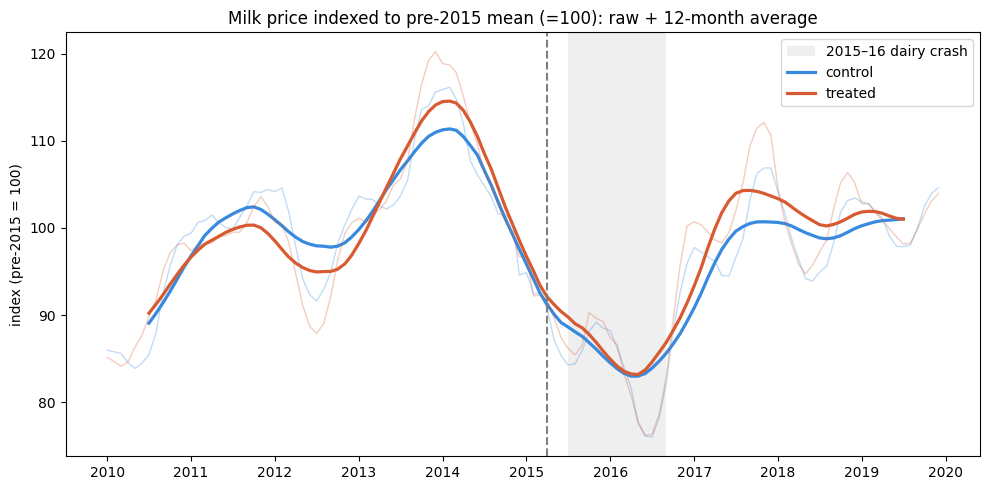

In [7]:
# Index each country to its own pre-2015 mean (=100), then average within group.
pre = panel[panel.date < ingest_price.ABOLITION_DATE]
base = pre.groupby("geo")["milk_price"].mean()
panel["idx"] = panel["milk_price"] / panel["geo"].map(base) * 100

gi = (panel.groupby(["date", "treated"])["idx"].mean()
            .unstack("treated").rename(columns={0: "control", 1: "treated"}))

# 2015-16 EU dairy price crash: an exogenous, EU-wide price shock (not the policy).
CRASH = (pd.Timestamp("2015-07-01"), pd.Timestamp("2016-09-01"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.axvspan(*CRASH, color="grey", alpha=0.12, lw=0, label="2015–16 dairy crash")
for col, color in [("control", "#378ADD"), ("treated", "#D85A30")]:
    ax.plot(gi.index, gi[col], color=color, alpha=0.30, lw=1)                  # raw
    ax.plot(gi.index, gi[col].rolling(12, center=True).mean(),
            color=color, lw=2.3, label=col)                                    # 12-month avg
ax.axvline(ingest_price.ABOLITION_DATE, ls="--", color="grey")
ax.set(title="Milk price indexed to pre-2015 mean (=100): raw + 12-month average",
       ylabel="index (pre-2015 = 100)")
ax.legend(); plt.tight_layout(); plt.show()

### Reading the plot: parallel pre-trends, but a common shock dominates the post-period

Two things stand out, and read together they already reshape what we expect from the estimation, though, as in the deliveries analysis, the plot only raises the questions; the event study answers them.

**Pre-2015: reasonably parallel.** Both groups rise to a ~2014 peak (treated marginally above, ~114 vs ~111) and fall together to ~90 by the break. There is a faint treated-above-control drift in 2013–14, but far milder than the pre-trend the deliveries analysis showed, for the parallel-trends assumption, this looks plausible.

**Post-2015: dominated by a common movement, not by a separation.** The two lines crash *together* to ~83 in 2016 and recover *together*. This is the **2015–16 dairy price crash**, an EU-wide price shock that hits both groups alike, exactly the textbook case of the two caveats we committed to in advance: integrated raw-milk markets and a genuine price shock in the post-period. The dominant feature of the post-period is co-movement, not divergence.

**The small difference that exists runs against the predicted sign.** This is the key point, and it is sharper than "the lines look similar." We predicted the treated group *below* control after 2015 (more supply → lower price). The plot shows the opposite: treated slightly *above* in 2017–18 (~104 vs ~100–101), converging to ~101 for both by 2019. So the eye shows **no** price-depressing effect in the hypothesised direction, at most a tiny gap, of the wrong sign.

**How to read this, with discipline rather than wishful thinking.** This is economically coherent, not a failure. Raw-milk prices form at the **EU level**, not country by country: a supply increase in the 12 treated Member States dilutes into the common market, so the local price effect that was visible in *volume* is here spread across everyone and nearly vanishes from the treated–control differential. The welfare story, "more volume but a lower price", can be true in aggregate at the EU level and still **not appear** in a treated-vs-control comparison, precisely because the price falls for all.

**But the plot decides nothing.** This is a group-averaged indexed mean: it can hide a real negative differential once country and month fixed effects strip out seasonality and the level, or it can confirm a near-zero. We cannot read either the sign or the significance from here. That is exactly why the next step is the **event study**, the same move as in the deliveries analysis, for the same reason: a 12-month smoother can manufacture or mask a trend, and the eye is not evidence.

**One honest update to our prior going in.** In the deliveries analysis we expected to confirm a strong, positive effect; here the realistic expectation is a **weak, null, or ambiguous** one, and we commit *in advance* to reporting whatever the estimation returns, including a null or a "boring" sign. A muted price effect alongside a clear volume effect **is** a finding, and a valuable one for this project: it is the signature of an integrated market, and showing that we can tell a segmented market from an integrated one is itself the point.

## 4. The event study

### From a suspicion to a test: the event study

The indexed plot suggests the two groups move largely together, with at most a tiny post-2015 gap of the *wrong* sign, but a 12-month rolling mean can manufacture or mask a trend, and the eye is not evidence. The event study turns that impression into a measurement.

A single-coefficient DiD compresses the whole post-period into one number. The event study unpacks it along time: one treated-vs-control coefficient **per year**, each relative to a fixed baseline. We omit **2014**, the last full pre-treatment year, so every coefficient reads as the treated–control gap in that year *relative to 2014* (the 2014 coefficient is therefore 0 by construction, not a result).

That structure puts numbers on both things we care about, with the interpretation fixed *before* looking:

- **Pre-2015 coefficients (2010–2013).** Under parallel trends these should be indistinguishable from zero: no systematic price gap before the policy. The plot looked close to parallel here, so we expect these near zero — and the event study is what confirms it rather than assuming it.
- **Post-2015 coefficients (2016–2019).** These trace the dynamic effect. Our prior, set before looking, is the opposite of the deliveries case: supply rose, so any price effect should be **negative**, the treated group's price falling relative to control. But we expect it **weak or null**, because raw-milk prices form at the EU level and an integrated market diffuses the local supply shock across treated and control alike. We commit to reporting whatever sign and magnitude the estimation returns, including a null.

Two specification choices, stated plainly:

- **Outcome is log price, not the indexed series.** Indexing was a *visual* device. In the regression, country fixed effects absorb the level gaps directly, and a log outcome makes each coefficient an approximate percentage effect — the principled version of "compare rates, not levels."
- **Fixed effects: country + month.** Country FE remove fixed structural differences; monthly time FE absorb everything common across countries in a given month, seasonality, and crucially the concurrent confounders. This last point bites harder for price than it did for volume: the **2015–16 dairy price crash** and the **2014 Russian import ban** are *price* events, and they dominate the post-period co-movement seen in the plot. Month FE absorb them **only to the extent they hit both groups alike**; any asymmetric incidence (the crash hitting the large treated exporters harder) is left in the residual and confounds the effect. Standard errors are clustered by country (prices are serially correlated month to month).

One honest caveat, unchanged: **2015 straddles the break** (quota until March, gone from April), so its annual coefficient mixes three treated-free months with nine treated ones, read it as transitional. The parallel-trends verdict rests on 2010–2013, which are clean.

###

Estimation:  OLS
Dep. var.: log_milk_price, Fixed effects: geo + date
sample: None = all
Inference:  CRV1
Observations:  2978

| Coefficient        |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2010:treated |     -0.009 |        0.022 |    -0.392 |      0.699 | -0.054 |   0.037 |
| year::2011:treated |     -0.039 |        0.021 |    -1.827 |      0.080 | -0.083 |   0.005 |
| year::2012:treated |     -0.052 |        0.023 |    -2.315 |      0.029 | -0.099 |  -0.006 |
| year::2013:treated |     -0.011 |        0.022 |    -0.523 |      0.606 | -0.057 |   0.034 |
| year::2015:treated |     -0.009 |        0.029 |    -0.324 |      0.749 | -0.070 |   0.051 |
| year::2016:treated |     -0.015 |        0.033 |    -0.464 |      0.647 | -0.083 |   0.053 |
| year::2017:treated |      0.022 |        0.027 |     0.828 |      0.416 | -0.033 |   0.078 |
| year::2018:

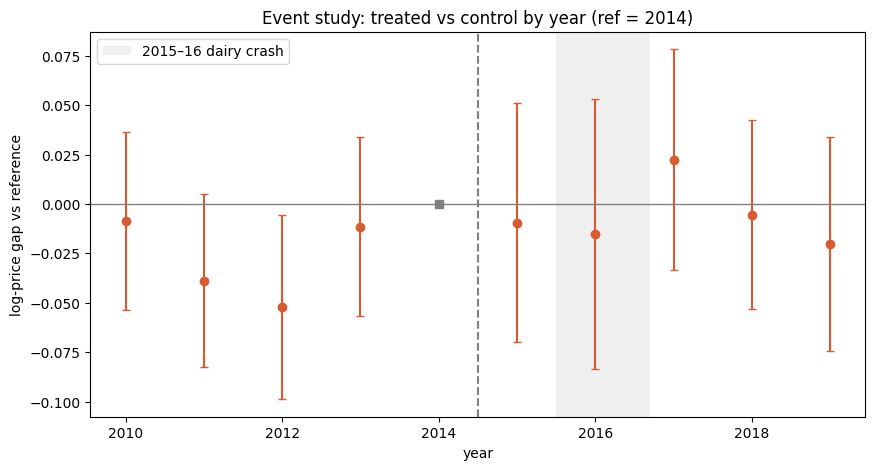

In [8]:
# Event study with 2014 as the reference year.
es = est.run_event_study(panel, ref_year=2014, outcome="milk_price")
es.summary()

# Plot the per-year coefficients (label reads "price").
est.plot_event_study(es, outcome="milk_price", crash=(2015.5, 2016.7))
plt.show()

###

Estimation:  OLS
Dep. var.: log_milk_price, Fixed effects: geo + date
sample: None = all
Inference:  CRV1
Observations:  2978

| Coefficient        |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2010:treated |      0.003 |        0.014 |     0.204 |      0.840 | -0.026 |   0.032 |
| year::2011:treated |     -0.027 |        0.011 |    -2.467 |      0.021 | -0.050 |  -0.004 |
| year::2012:treated |     -0.041 |        0.018 |    -2.269 |      0.033 | -0.078 |  -0.004 |
| year::2014:treated |      0.011 |        0.022 |     0.523 |      0.606 | -0.034 |   0.057 |
| year::2015:treated |      0.002 |        0.037 |     0.053 |      0.958 | -0.074 |   0.078 |
| year::2016:treated |     -0.004 |        0.036 |    -0.108 |      0.915 | -0.078 |   0.070 |
| year::2017:treated |      0.034 |        0.018 |     1.926 |      0.066 | -0.002 |   0.070 |
| year::2018:

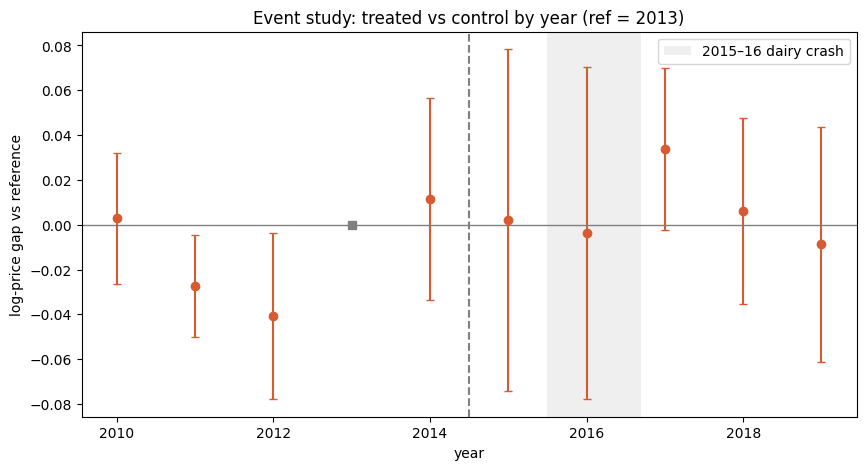

In [9]:
# Robustness: re-anchor the baseline on 2013.
es13 = est.run_event_study(panel, ref_year=2013, outcome="milk_price")
es13.summary()

# Plot the per-year coefficients (label reads "price").
est.plot_event_study(es13, outcome="milk_price", crash=(2015.5, 2016.7))
plt.show()

### Reading the event study: a robust null, and what it does and doesn't mean

The plot's impression, two groups moving together, at most a tiny post-2015 gap of the wrong sign, survives the move to numbers. The verdict is clean: **there is no detectable price effect, and the null is robust.**

**Post-2015 (the effect).** With 2014 as reference, the four post coefficients are −0.015, +0.022, −0.005, −0.020, **none significant** (p between 0.42 and 0.82), with no monotonic build-up and signs that flip year to year (2017 is positive). The 2019 "endpoint" is −0.020 with a CI of [−0.074, 0.034] that crosses zero comfortably. Re-anchoring on 2013 gives the same picture (2019 at −0.009, all insignificant), so the reading does not depend on the base year. The within-R² of **0.024** says it from another angle: once country and month fixed effects are in, the treated×year interactions explain almost nothing. This is not the negative effect we predicted, it is no effect.

**Pre-2015 (the parallel-trends read).** One honest qualification. There is a **2011–2012 dip**, treated below control, 2012 at −0.052 (p ≈ 0.03), 2011 marginal, significant under both anchors. But it **closes**: 2013 and 2014 return to ~0. This is the same shape the deliveries analysis showed, an early deficit that recovers, not an accelerating anticipation ramp toward 2015. So the pre-period is not perfectly flat, but the deviation is early and gone before the break, and the post-period nulls are measured against an already-recovered 2013–14 baseline (which is why the 2013-vs-2014 robustness is a non-event).

**What the null means, read with discipline.** This confirms what the plot suggested, and the reason is structural, not a weakness of the data. The supply shock in the 12 treated Member States does **not** show up as a treated-vs-control price differential because raw-milk prices form at the **EU level**, above the level at which the treatment is defined. And here is the identification point worth declaring plainly: **the controls are not a clean counterfactual for price**, because they sit in the *same* market that sets the price. A price effect that moves treated and control together is, by construction, indistinguishable from no effect under a difference-in-differences design. The null is therefore as much a statement about the **reach of this design for this outcome** as about the world.

**This is a result, not a failure.** A clear volume effect (≈ +11%) alongside a null price *differential* is the signature of an **integrated market**, and recognising when a treated-vs-control design can identify an effect and when it cannot is itself the point of the exercise. For the income finale it has a direct consequence: relative to the control group, farm income moves essentially with the volume effect, with no measurable relative price penalty, while we remain explicit that we **cannot** identify an EU-wide aggregate price decline, because there is no counterfactual for "the entire EU."

**Where this leaves the design.** The next step, synthetic control, shares this exact limitation, its donors are in the same price-forming market, so it is expected to *confirm* the null under different assumptions rather than overturn it. We run it anyway, for the same structural parallelism with the deliveries analysis and to show the null is robust to a method that does not assume parallel trends; but we frame it in advance as the corroboration of a null, with the identification caveat stated up front.

## 5. Synthetic control

## Second method: synthetic control

The event study left the price analysis in a specific place: a **robust null** (no post-2015 treated-vs-control gap, insignificant under either base year), sitting on a pre-trend that is *nearly* parallel but carries an early 2011–2012 dip that closes before the break. A single method cannot carry a conclusion on its own, and that holds just as much for a null as for an effect: we need a *second* estimate, built on *different* assumptions, to check that the null is a property of the world and not an artefact of the DiD's parallel-trends requirement. If both methods agree on ~zero, the result does not hinge on the assumption that wobbles.

Synthetic control is that second method. Instead of averaging all controls and assuming they move parallel to the treated (DiD), it builds, for each treated country, a bespoke counterfactual, a weighted combination of control countries chosen to reproduce *that country's own* pre-2015 trajectory. It therefore **does not assume parallel trends**; it reconstructs each treated unit's pre-period path directly, absorbing the early 2011–2012 dip by construction. Here its job is not to rescue a fragile effect but to **stress-test a null**: does the treated–synthetic gap stay flat after 2015, the way DiD says it should?

Design choices, each stated to be defended:

- **One synthetic control per treated country (12), donors = the 13 price controls.** Never other treated units (contaminated by the same policy). The donor pool is smaller than in the deliveries analysis, the UK is absent from the price data and Croatia and Malta were dropped, and that thinner pool is itself a limitation to keep in view. Fitting each country separately also exposes any heterogeneity behind the average null.
- **Convex weights (w ≥ 0, sum w = 1).** The counterfactual is an interpolation *inside* the donor convex hull, a mix of real countries, never an extrapolation like "France × 3 − Poland × 2". This is Abadie's key safeguard against fantasy counterfactuals; where it fails to reach extreme units, the augmented variant follows, judged by the same pre-RMSPE gauge.
- **Match on the monthly pre-2015 log path (2010–2014).** Logs so the gap reads as a ~% effect, directly comparable to the DiD coefficients.

The treated-minus-synthetic **gap** is the estimate: flat near zero before 2015 (a good synthetic reproduces the past), and if the policy moved the price relative to the counterfactual, opening up after. Our prior, set before looking, is that it **stays flat**: the event study found no differential, and the reason is structural, so synthetic control should reproduce the same near-zero. The pre-period gap doubles as the built-in honesty check: if it is *not* flat, the synthetic failed and its post gap is not to be trusted.

**One caveat carried forward, stated up front.** Synthetic control does **not** repair the identification limit the event study exposed. Its donors are EU control countries sitting in the *same* integrated, EU-level price-forming market as the treated. So a price effect common to both groups stays invisible here too: this method can confirm that the *treated-vs-control differential* is null, but it cannot recover an EU-wide aggregate price decline, for which no counterfactual exists. We read a flat post-2015 gap as corroboration of the differential null under different assumptions not as evidence that the abolition left farm-gate prices untouched in absolute terms.

In [10]:
# Donor-coverage policy: a synthetic-control donor needs a complete 2010–2019
# series, else its scattered pre-period gaps would truncate every treated unit's
# pre-block through the row-wise alignment in _pre_block. So donors are restricted
# to full-coverage controls (RO/BG/SE drop) — for SC only; all three stay in the
# DiD sample. Treated units are kept regardless (LU is short post-2018 but its
# pre-period is complete). HR/MT were already dropped upstream.
n_months = panel.groupby("geo").size()
full_cov = set(n_months[n_months == 120].index)
panel_sc = panel[(panel.treated == 1) | (panel.geo.isin(full_cov))].reset_index(drop=True)

print("SC donors (full-coverage controls):",
      sorted(panel_sc.loc[panel_sc.treated == 0, "geo"].unique()))
print("excluded from donor pool:",
      sorted(set(panel.loc[panel.treated == 0, "geo"].unique()) - full_cov))

SC donors (full-coverage controls): ['CZ', 'EL', 'FI', 'FR', 'HU', 'LT', 'LV', 'PT', 'SI', 'SK']
excluded from donor pool: ['BG', 'RO', 'SE']


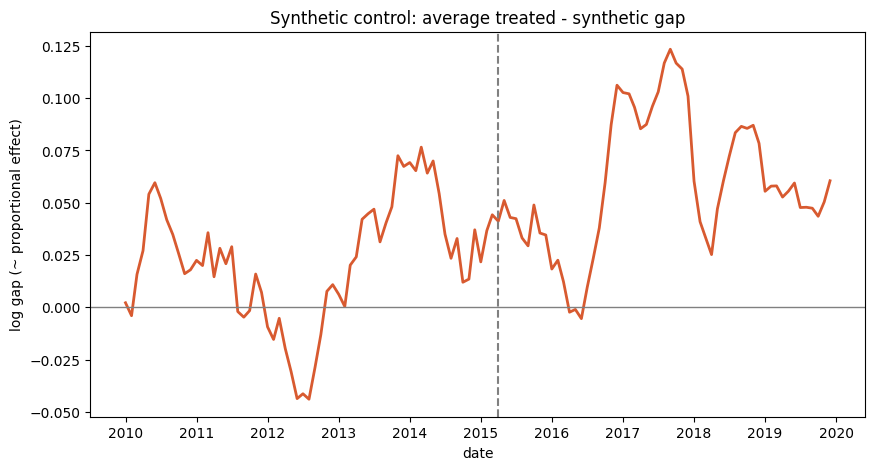

mean effect post (log): 0.059


In [11]:
# One synthetic control per treated country (standard, convex weights).
results, gaps, avg_gap = synth.run_all_treated(panel_sc, pre_end="2014-12-01",
                                               outcome="milk_price")

# Average treated - synthetic gap over time (flat pre-2015 = good fit).
synth.plot_average_gap(avg_gap)
plt.show()

# Size of the effect in the post period (average log gap ≈ % effect).
print("mean effect post (log):",
      round(avg_gap[avg_gap.index >= "2015-04-01"].mean(), 3))

In [13]:
# Per-country post effect and pre-period fit quality.
print("post effects per country:")
print(synth.post_effects(gaps).round(3))

post effects per country:
CY    0.402
AT    0.079
PL    0.066
LU    0.037
IT    0.035
NL    0.025
DK    0.020
DE    0.016
ES    0.014
IE    0.010
BE    0.001
EE   -0.001
dtype: float64


In [14]:
# We also have a look to the pre-RMSPE
print("\npre-RMSPE (lower = better):")
print(synth.pre_rmspe_table(results).round(3))


pre-RMSPE (lower = better):
ES    0.020
IT    0.029
PL    0.033
AT    0.036
EE    0.037
DK    0.041
DE    0.042
LU    0.044
BE    0.056
IE    0.060
NL    0.061
CY    0.228
dtype: float64


### Reading the standard synthetic control: read the fit, not the headline

The headline average post gap is **+0.059**, but that figure is poisoned, and the reason is the finding, exactly as in the deliveries analysis. Read the diagnostic (pre-RMSPE), not the effect.

**The pre-RMSPE splits the units cleanly.** Eleven countries fit their pre-period well, in a compact band (0.020–0.061), and then there is a sharp jump: **Cyprus at 0.228**, nearly 4× the next worst (NL, 0.061). A synthetic control is supposed to reproduce the pre-period almost exactly; a pre-RMSPE that large means Cyprus's counterfactual is **failing before the policy**, so its +0.402 post gap is not an effect, it is an artefact of a bad fit. And because it is large, it single-handedly drags the 12-country average upward. The average-gap plot shows this directly: flat pre-2015 for the well-fit units, with the post-period dominated by the Cyprus hump.

**Excluding Cyprus, the average post gap falls to ≈ +0.028**, and that number must be read against the fit noise. The eleven well-fit units run from BE +0.001 to AT +0.079, and the residual +0.028 is of the **same order as the pre-period fit errors themselves** (~0.04). This is the decisive contrast with deliveries, where the effect (~0.11) sat far above the noise (~0.02), an unmistakable signal. Here **signal ≈ noise**, which is the fingerprint of a null, not a +2.8% effect.

**The sign cuts against the prediction, and is not worth overselling either way.** What little there is comes out **positive**, not negative, so the synthetic control, like the event study, finds no price-depressing effect; if anything a faint upward wobble, attributable to noise. The event study leaned slightly negative, the synthetic control slightly positive; both are tiny and inside the noise band. The **convergent** message is "no robust differential," not "a +2.8% effect." Neither sign should be read as real.

**Cyprus is a textbook pre-RMSPE cut**, the price analogue of Ireland in the deliveries analysis. Sorted, the pre-RMSPE shows a compact group up to 0.061, then a wide empty gap to Cyprus at 0.228. The only outlier, alone across that gap, is Cyprus, so the defensible cut falls in the empty space (e.g. 0.12): **11 units kept, Cyprus alone excluded.** Cyprus is a small, atypical market that sits at the edge of the donor convex hull, which is precisely the kind of unit convex interpolation cannot reach.

**Next step, by the same standard we applied to quantity.** Before excluding Cyprus by hand, we try the **augmented (ridge) synthetic control**, which relaxes the non-negativity constraint to permit regularised extrapolation toward edge units. In the deliveries analysis this rescued Cyprus (1.185 → 0.038). The test is the same objective gauge: does Cyprus's pre-RMSPE drop into the well-fit range? If it does, we keep it; if not, the cut stands. Either way — Cyprus in or out — the conclusion (a null, with a tiny positive wobble inside the noise) will not move; running it shows we hold price to the same standard as quantity.

## 6. Augmented (ridge) synthetic control

### Augmented synthetic control: extrapolating, with a leash

The standard synthetic control fit eleven of the twelve treated countries well (pre-RMSPE 0.020–0.061) and failed on one: **Cyprus, at 0.228 — about 4× the next worst.** The cause is structural, not incidental. Convex weights confine the synthetic to the donors' convex hull, and Cyprus is a small, atypical market that sits at the *edge* of that hull: no convex mix of the larger control economies can reach it. It is the price analogue of Germany and Ireland in the deliveries analysis, different units, same geometry. Excluding it by hand is the easy move, but before taking it we relax the binding constraint and let the method try, holding price to exactly the standard we applied to quantity.

The augmented (ridge) synthetic control keeps the same objective, reproduce each treated unit's pre-2015 path, but **drops the non-negativity constraint**, so weights may be negative. A negative weight is extrapolation: it lets the synthetic climb beyond the donor envelope to reach an edge unit like Cyprus, which pure interpolation never could. Unconstrained, that freedom would overfit the pre-period and produce wild counterfactuals, so it is leashed by a ridge penalty λ‖w‖²: small λ allows more extrapolation (lower bias, higher variance), large λ pulls back toward stability. This is the bias–variance trade-off made explicit, and λ is chosen by pre-period cross-validation rather than by hand. Keeping the sum-to-one constraint while relaxing non-negativity turns the problem into a constrained ridge regression, solved in closed form via a single Lagrange multiplier (no iterative optimiser), see `synth.py`.

The decisive point is how we judge whether this helped: not by whether the post-period gaps now look nicer, but by the **same objective gauge as before**, does Cyprus's pre-RMSPE drop into the well-fit range? Extrapolation that improves pre-fit is doing its job; extrapolation that doesn't would just be added noise, and Cyprus would stand by the pre-RMSPE cut after all. The comparison table below is that test.

**What this does and does not change.** This is a fit question, not an identification one. Augmentation can rescue Cyprus's *counterfactual*, but it cannot change what the method can identify: donors and treated still share the same EU-level price-forming market, so the differential null stands regardless. And the conclusion is robust to the outcome of this step either way, whether Cyprus is rescued into the average or excluded by the cut, the treated–synthetic gap remains a tiny wobble inside the noise. We run it for consistency with the deliveries analysis and to show the null survives a method that permits extrapolation, not because the headline depends on it.